## Energy and time spectra

For prompt gamma timing / fast neutron timing, and a little bit for prompt gamma / fast netron spectroscopy reasons

Two distinctions with timing:
1) Raw timing with FLUKA data
2) Timing after post-processing

1\) should be fine enough for PGT, but not quite the same for FNT.
Neutron production may take some time, so there is a chance for the FNT and PGT spectra to overlap.

Post-processing of the time
1) Simply plot the times coming from the FLUKA MC simulations
2) Account for the cyclotron radiofrequency. Take time minus the time between RF pulses. 

RF: 106.3 MHz -> Cycles of 9.41

2\) eqautes to: Cycle time =  9.41 ns * modulus(FLUKA_time / 9.41)

In other words, it is as if we collect a new specter every 9.41 ns. In the end the total/average time specter can be made

NB: Times after post-processing are given in µs, not ns!

In [34]:
cyclotron_frequency = 106.3 # MHz
print(f"Cyclotron period: {round(1e9/106.3e6, 3)} ns")
cyclotron_period = 9.4073 # ns

Cyclotron period: 9.407 ns


In [35]:
import numpy as np
import matplotlib.pylab as plt
import time
import math

from mgdraw_output_reader_NOVO_v04 import DetectionDataStorage

primaries_per_spawn = 1.5e7
number_of_files = 349
number_of_primaries = primaries_per_spawn * number_of_files

beam_current = 2.0 # nA

Loading testing data: NOVO51 5e9 primaries version

In [36]:
PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Simulations\2025-12_OncoRay_round2\NOVO51_5e9\scintillator_interactions"

test_data = DetectionDataStorage(folder_path=PATH, primaries_per_spawn=primaries_per_spawn, max_files=number_of_files, FLUKA_to_meas_coords=True)

test_data.load_data(mgdraw_version_8_plus=False)

Reading 349 scintillator_interactions.txt-files
Total time used on data collection: 98.01 s


In [37]:
test_data.filter_hits(time_structure=None)


-----------ICODE FILTERING-----------
Raw hit filtering complete. Time used: 53.27 s
Total number of lines: 3035175
Number of lines kept: 691468 (22.8%)
Number of lines rejected: 2343707 (77.2%)

-----------HIT MERGING-----------
Merging complete. Time used: 20.91 s
Overlaps found: 96524
Total number of hit histories > 10/200 keV: 376530
Number of gamma hit histories > 10 keV: 220341
Number of neutron hit histories > 200 keV: 155537
Number of combo hit histories > 200 keV: 652


In [38]:
def estimate_FLUKA_time(time_stamp, NCASE, beam_current = 2, frequency=cyclotron_frequency):
    protons_per_bunch = beam_current * 1e-9 / 1.6e-19 * (1e-6 / frequency)
    proton_bunch_number = int(NCASE / protons_per_bunch)

    FLUKA_time = time_stamp - (proton_bunch_number * cyclotron_period * 1e-3)   # Convert from ns to µs

    return FLUKA_time

#### Hit times after post-processing

Text(0, 0.5, 'Counts')

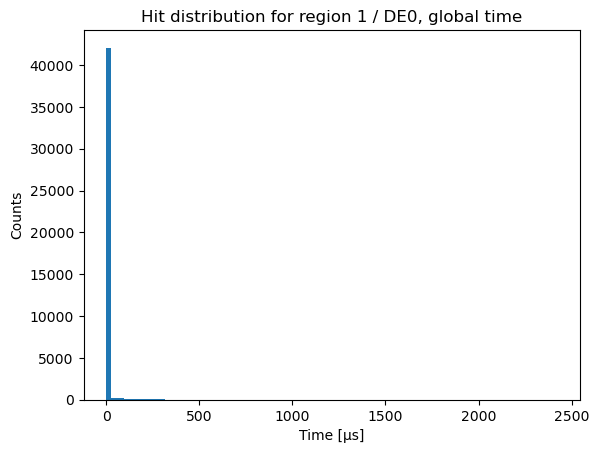

In [39]:
all_hits = test_data.all_hits

all_hits_ncases = all_hits[:, 0]    # NCASEs
all_hits_regions = all_hits[:, 12]  # Regions
all_hits_times = all_hits[:, 14]    # Times

# Only include hits for the first scintillator
all_hits_region_mask = all_hits_regions==1
all_hits_region_ncases = all_hits_ncases[all_hits_region_mask]
all_hits_region_times = all_hits_times[all_hits_region_mask]

plt.figure()
plt.title(f"Hit distribution for region 1 / DE0, global time")
plt.hist(all_hits_region_times, bins=100)
plt.xlabel("Time [µs]")
plt.ylabel("Counts")

#### Hit distribution in FLUKA times

Text(0, 0.5, 'Counts')

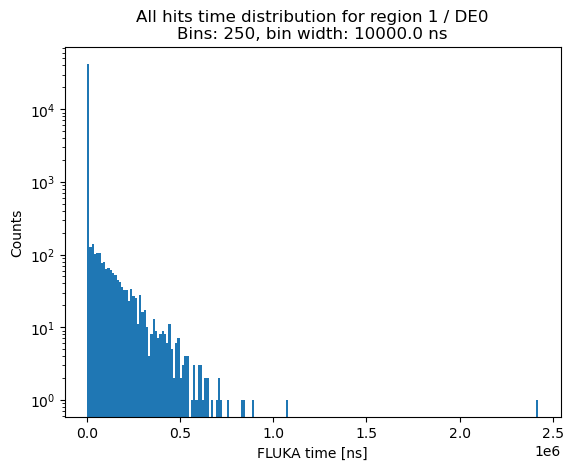

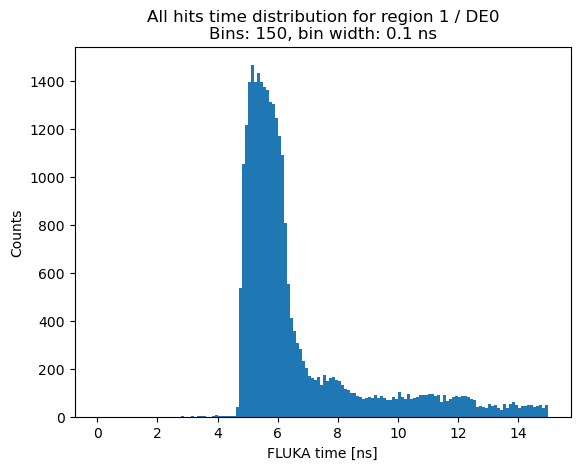

In [40]:
#all_hits_region_times_mod = []
#for NCASE, hit_time in zip(all_hits_region_ncases, all_hits_region_times):
#    all_hits_region_times_mod.append(estimate_FLUKA_time(hit_time, NCASE))

all_hits_region_times_mod = 1000 * np.array(all_hits_region_times)

plt.figure()
time_width = 1e4     # ns
max_time = 2.5e6   # ns
time_bins = np.arange(0.0, max_time + time_width, time_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]
plt.title(f"All hits time distribution for region 1 / DE0\nBins: {int(max_time/time_width)}, bin width: {time_width} ns")
plt.hist(all_hits_region_times_mod, bins=200)
plt.xlabel("FLUKA time [ns]")
plt.ylabel("Counts")
plt.yscale("log")

plt.figure()
time_width = 0.1     # ns
max_time = 15   # ns
time_bins = np.arange(0.0, max_time + time_width, time_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

plt.title(f"All hits time distribution for region 1 / DE0\nBins: {int(max_time/time_width)}, bin width: {time_width} ns")
plt.hist(all_hits_region_times_mod, bins=time_bins)
plt.xlabel("FLUKA time [ns]")
plt.ylabel("Counts")
#plt.yscale("log")

### Testing for only PGs

Text(0, 0.5, 'Counts')

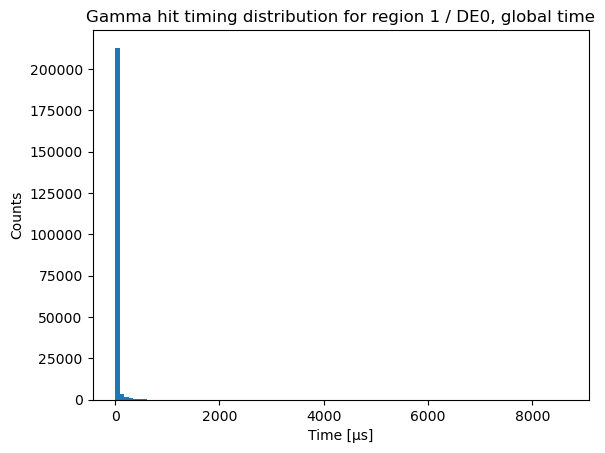

In [41]:
gamma_hits = test_data.gamma_hits

gamma_hits_ncases = gamma_hits[:, 0]    # NCASEs
gamma_hits_energies = gamma_hits[:, 7]  # Energy depositions
gamma_hits_regions = gamma_hits[:, 12]  # Regions
gamma_hits_times = gamma_hits[:, 14]    # Times

# Only include hits for the first scintillator
gamma_hits_region_mask = gamma_hits_regions>=1
gamma_hits_region_energies = gamma_hits_energies[gamma_hits_region_mask]
gamma_hits_region_ncases = gamma_hits_ncases[gamma_hits_region_mask]
gamma_hits_region_times = gamma_hits_times[gamma_hits_region_mask]

plt.figure()
plt.title(f"Gamma hit timing distribution for region 1 / DE0, global time")
plt.hist(gamma_hits_region_times, bins=100)
plt.xlabel("Time [µs]")
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

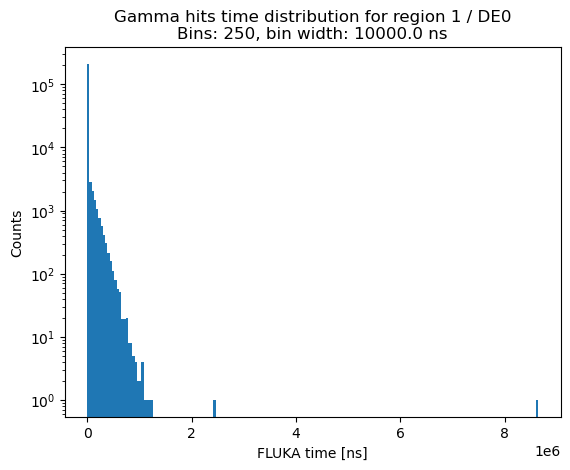

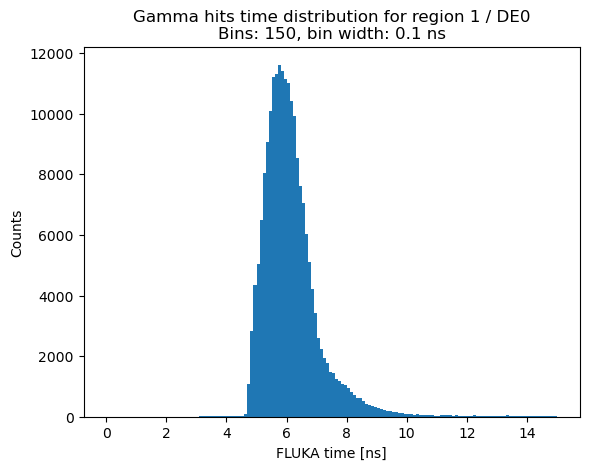

In [42]:
gamma_hits_region_times_mod = 1000 * np.array(gamma_hits_region_times)  # Convert from µs to ns

plt.figure()
time_width = 1e4     # ns
max_time = 2.5e6   # ns
time_bins = np.arange(0.0, max_time + time_width, time_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]
plt.title(f"Gamma hits time distribution for region 1 / DE0\nBins: {int(max_time/time_width)}, bin width: {time_width} ns")
plt.hist(gamma_hits_region_times_mod, bins=200)
plt.xlabel("FLUKA time [ns]")
plt.ylabel("Counts")
plt.yscale("log")

plt.figure()
time_width = 0.1     # ns
max_time = 15   # ns
time_bins = np.arange(0.0, max_time + time_width, time_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

plt.title(f"Gamma hits time distribution for region 1 / DE0\nBins: {int(max_time/time_width)}, bin width: {time_width} ns")
plt.hist(gamma_hits_region_times_mod, bins=time_bins)
plt.xlabel("FLUKA time [ns]")
plt.ylabel("Counts")
#plt.yscale("log")

### For FNs

Text(0, 0.5, 'Counts')

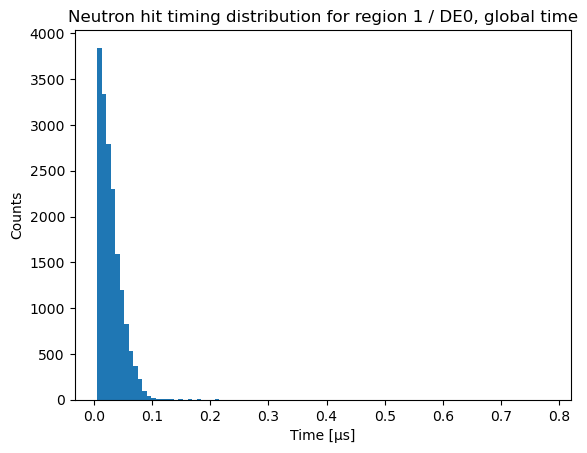

In [43]:
neutron_hits = test_data.neutron_hits

neutron_hits_ncases = neutron_hits[:, 0]    # NCASEs
neutron_hits_energies = neutron_hits[:, 7]  # Energy depositions
neutron_hits_regions = neutron_hits[:, 12]  # Regions
neutron_hits_times = neutron_hits[:, 14]    # Times

# Only include hits for the first scintillator
neutron_hits_region_mask = neutron_hits_regions==1
neutron_hits_region_ncases = neutron_hits_ncases[neutron_hits_region_mask]
neutron_hits_region_times = neutron_hits_times[neutron_hits_region_mask]
neutron_hits_region_energies = neutron_hits_energies[neutron_hits_region_mask]

plt.figure()
plt.title(f"Neutron hit timing distribution for region 1 / DE0, global time")
plt.hist(neutron_hits_region_times, bins=100)
plt.xlabel("Time [µs]")
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

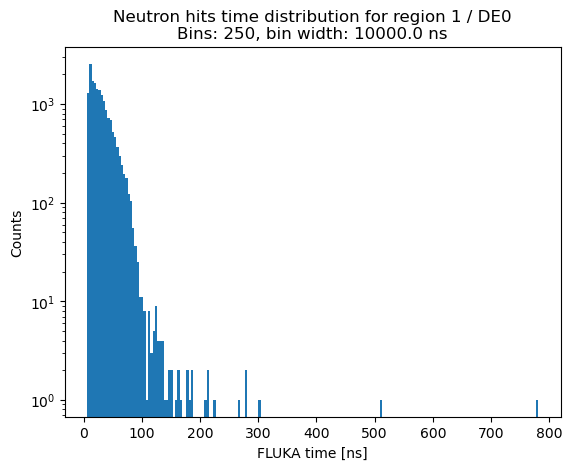

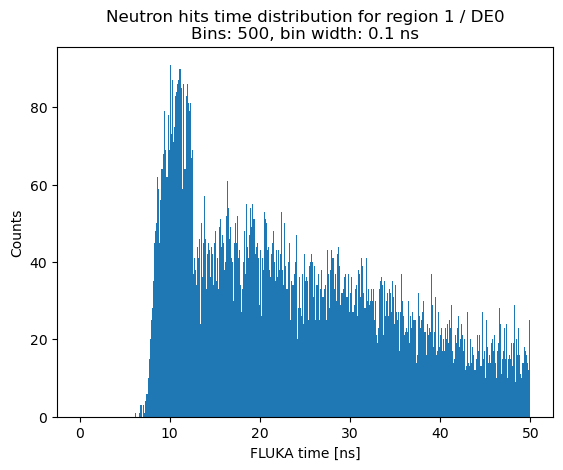

In [44]:
neutron_hits_region_times_mod = 1000 * np.array(neutron_hits_region_times)  # Convert from µs to ns

plt.figure()
time_width = 1e4     # ns
max_time = 2.5e6   # ns
time_bins = np.arange(0.0, max_time + time_width, time_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]
plt.title(f"Neutron hits time distribution for region 1 / DE0\nBins: {int(max_time/time_width)}, bin width: {time_width} ns")
plt.hist(neutron_hits_region_times_mod, bins=200)
plt.xlabel("FLUKA time [ns]")
plt.ylabel("Counts")
plt.yscale("log")

plt.figure()
time_width = 0.1     # ns
max_time = 50   # ns
time_bins = np.arange(0.0, max_time + time_width, time_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

plt.title(f"Neutron hits time distribution for region 1 / DE0\nBins: {int(max_time/time_width)}, bin width: {time_width} ns")
plt.hist(neutron_hits_region_times_mod, bins=time_bins)
plt.xlabel("FLUKA time [ns]")
plt.ylabel("Counts")
#plt.yscale("log")

### Plotting in combination

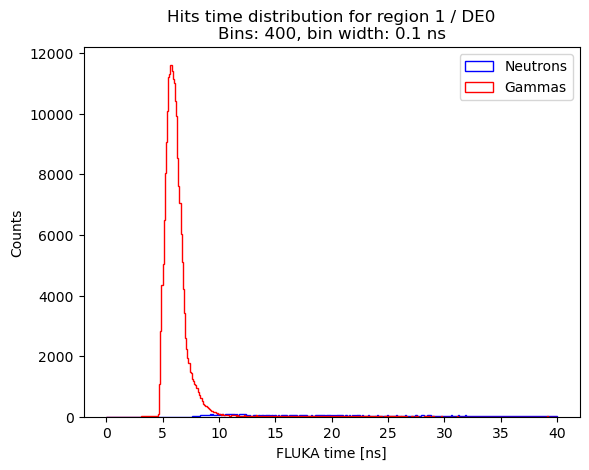

In [45]:
plt.figure()
time_width = 0.1     # ns
max_time = 40   # ns
time_bins = np.arange(0.0, max_time + time_width, time_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

plt.title(f"Hits time distribution for region 1 / DE0\nBins: {int(max_time/time_width)}, bin width: {time_width} ns")
plt.hist(neutron_hits_region_times_mod, bins=time_bins, color="blue", label="Neutrons", histtype="step")
plt.hist(gamma_hits_region_times_mod, bins=time_bins, color="red", label="Gammas", histtype="step")
#plt.hist(all_hits_region_times_mod, bins=time_bins, color="gray", label="All hits", histtype="step", ls="--")

plt.xlabel("FLUKA time [ns]")
plt.ylabel("Counts")
plt.legend()


Text(0.5, 1.0, 'Gamma hit time-energy distribution, region 1 / DE0\n Time binning: 0.1 ns, Energy binning: 0.1 MeV')

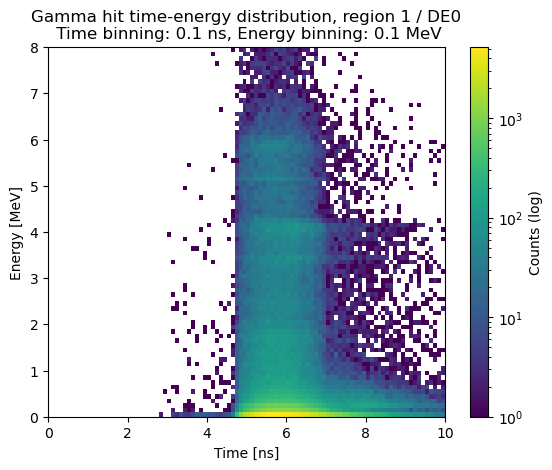

In [52]:
plt.figure()
max_energy = 8  # MeV
max_time = 10   # ns

from matplotlib.colors import LogNorm

gamma_hits_region_TE_mask = (gamma_hits_region_times_mod < max_time) & (gamma_hits_region_energies < max_energy) #& (gamma_hits_region_energies > 1.0)
gamma_hits_region_times_mod_timecut = gamma_hits_region_times_mod[gamma_hits_region_TE_mask]
gamma_hits_region_energies_timecut = gamma_hits_region_energies[gamma_hits_region_TE_mask]

dE = 0.1    # MeV
dt = 0.1    # ns
energy_bins = np.arange(0, max_energy + dE, dE)
time_bins = np.arange(0, max_time + dt, dt)

H, xedges, yedges = np.histogram2d(
    gamma_hits_region_times_mod_timecut,
    gamma_hits_region_energies_timecut,
    bins=[time_bins, energy_bins]
)

plt.imshow(
    H.T,
    origin="lower",
    aspect="auto",
    extent=[0, 10, 0, 8],
    cmap="viridis",
    norm=LogNorm()
)

cbar = plt.colorbar()
cbar.set_label("Counts (log)")

#plt.hist2d(gamma_hits_region_times_mod_timecut, gamma_hits_region_energies_timecut, bins=50)
plt.xlabel("Time [ns]")
plt.ylabel("Energy [MeV]")
#plt.legend()
plt.title(f"Gamma hit time-energy distribution, region 1 / DE0\n Time binning: {dt} ns, Energy binning: {dE} MeV")

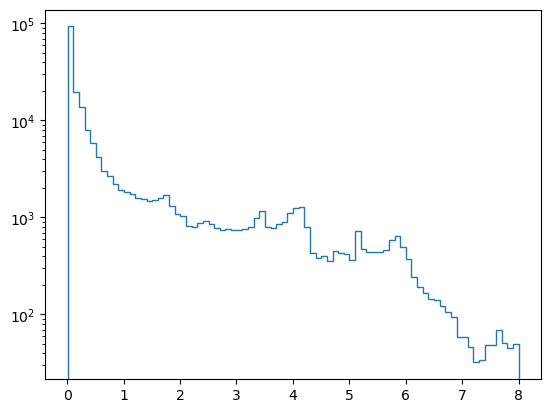

In [47]:
plt.figure()
plt.hist(gamma_hits_region_energies_timecut, histtype="step", bins=80)
plt.yscale("log")